<a href="https://colab.research.google.com/github/RMoulla/IAY_Mars/blob/main/TP_Churn_IAY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Travaux pratiques : explication et prédiction du churn avec du machine learning**

In [ ]:
import pandas as pd
dataset = pd.read_csv('customer_churn.csv')
dataset.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [ ]:
# Statistiques descriptives
dataset.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,0.166667
std,6.127560,2408.644532,0.499921,1.274449,1.764836,0.372885
min,22.000000,100.000000,0.000000,1.000000,3.000000,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,1.000000


## Analyse exploratoire des données

<Axes: xlabel='Churn', ylabel='count'>

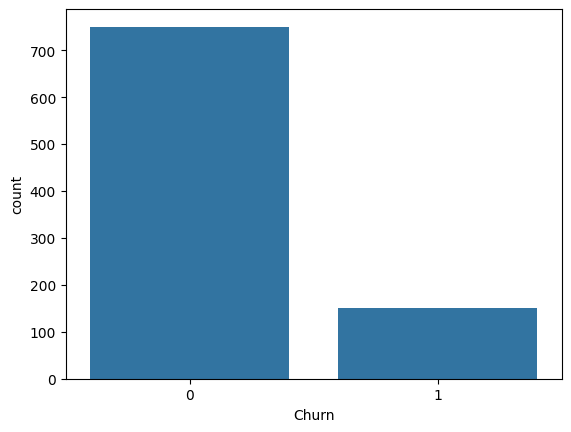

In [ ]:
# Visualiser la vatiable churn
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='Churn', data=dataset)

<Axes: xlabel='Churn', ylabel='Age'>

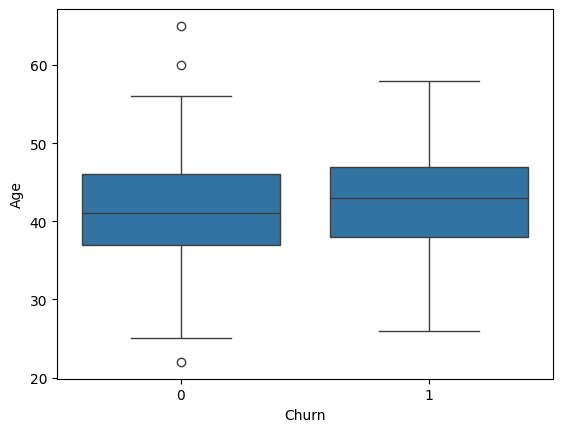

In [ ]:
# Visualiser graphiquement le churn en fonction de l'âge

sns.boxplot(x='Churn', y='Age', data=dataset)



<Axes: xlabel='Churn', ylabel='Total_Purchase'>

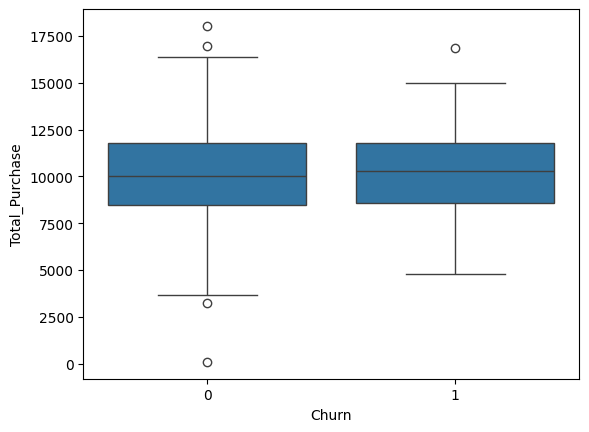

In [ ]:
# Visualiser le churn en fonction de total purchase
sns.boxplot(x='Churn', y='Total_Purchase', data=dataset)

<Axes: xlabel='Churn', ylabel='Years'>

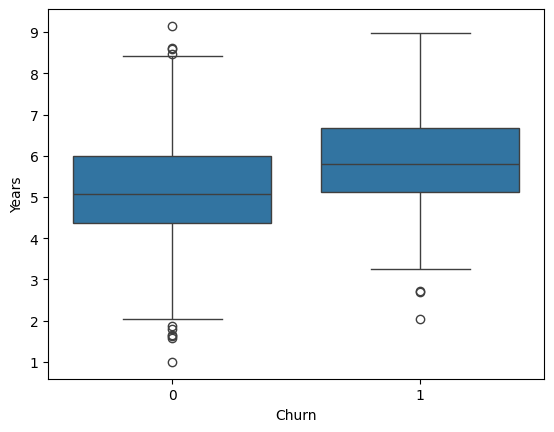

In [ ]:
# Visualiser le churn en fonction de Years
sns.boxplot(x='Churn', y='Years', data=dataset)

<Axes: xlabel='Churn', ylabel='Num_Sites'>

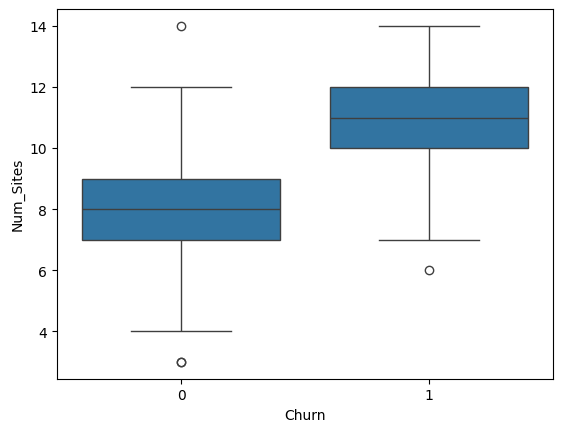

In [ ]:
# Visualiser le churn en fonction de Num_Sites
sns.boxplot(x='Churn', y='Num_Sites', data=dataset)

<Axes: xlabel='Churn', ylabel='count'>

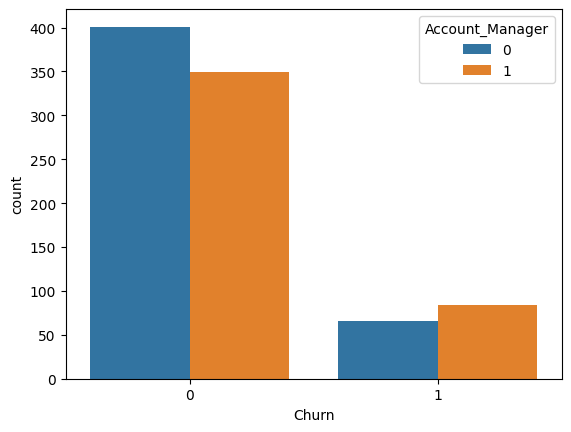

In [ ]:
# Visualiser le churn en fonction de Account Manager
sns.countplot(x='Churn', hue='Account_Manager', data=dataset)

# Modélisation des données



In [ ]:
dataset.columns

Index(['Names', 'Age', 'Total_Purchase', 'Account_Manager', 'Years',
       'Num_Sites', 'Onboard_date', 'Location', 'Company', 'Churn'],
      dtype='object')

In [ ]:
# Définition des features X et du label y

X = dataset.drop(['Churn', 'Names', 'Onboard_date', 'Location', 'Company'], axis=1)
y = dataset['Churn']
X.head()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites
0,42.0,11066.80,0,7.22,8.0
1,41.0,11916.22,0,6.50,11.0
2,38.0,12884.75,0,6.67,12.0
3,42.0,8010.76,0,6.71,10.0
4,37.0,9191.58,0,5.56,9.0


In [ ]:
# Partitionner les données en train et test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Entraîner un modèle de régression logistique avec statsmodels

import statsmodels.api as sm
X_train_const = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.259923
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                  630
Model:                          Logit   Df Residuals:                      624
Method:                           MLE   Df Model:                            5
Date:                Mon, 23 Mar 2026   Pseudo R-squ.:                  0.4295
Time:                        15:16:13   Log-Likelihood:                -163.75
converged:                       True   LL-Null:                       -287.05
Covariance Type:            nonrobust   LLR p-value:                 2.954e-51
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -20.0003      2.124     -9.417      0.000     -24.163     -15.838
Age           

In [ ]:
# Prédire sur le test
X_test_const = sm.add_constant(X_test)
y_pred = result.predict(X_test_const)
y_pred

y_pred_class = [1 if prob > 0.3 else 0 for prob in y_pred]

In [ ]:
# Calculer les performances prédictives du modèles : accuracy, rappel, precision, f1 score

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
print("Accuracy:", accuracy_score(y_test, y_pred_class))
print("Recall:", recall_score(y_test, y_pred_class))
print("Precision:", precision_score(y_test, y_pred_class))
print("F1 score:", f1_score(y_test, y_pred_class))

Accuracy: 0.9
Recall: 0.7209302325581395
Precision: 0.6739130434782609
F1 score: 0.6966292134831461


$$recall = \frac{VP}{VP+FN}$$ \\
$$precision = \frac{VP}{VP+FP}$$